In [4]:
from sklearn.datasets import make_regression
import pandas as pd 


In [5]:
import numpy as np

In [6]:
x,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

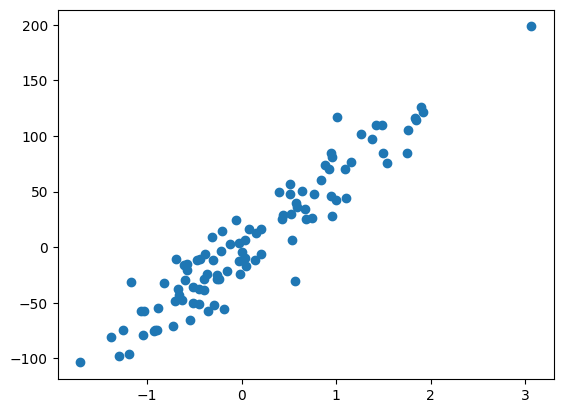

In [7]:
import matplotlib.pyplot as plt
plt.scatter(x,y)

In [8]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [9]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2)

In [10]:
reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
reg.coef_

array([62.80457232])

In [12]:
reg.intercept_

np.float64(-0.49000768660138583)

In [107]:
class Gdregression:
    def __init__(self,learning_rate,epochs):
        self.m = 1
        self.b = 120
        self.lr = learning_rate
        self.epochs = epochs
        
    def fit(self,x_train,y_train):
        for i in range(self.epochs):
            b_loss_slops = -2* np.sum(y_train - (self.m*x_train).ravel() - self.b)
            m_loss_slops = -2* np.sum((y_train - (self.m*x_train).ravel() - self.b)*x_train.ravel())

            b_step_size = self.lr*b_loss_slops
            m_step_size = self.lr*m_loss_slops

            self.b = self.b - b_step_size
            self.m = self.m - m_step_size

        print(b_loss_slops)
        print(self.b)
        print(m_loss_slops)
        print(self.m)
    def predict(self, x):
        return self.m * x + self.b
            


In [143]:
from sklearn.metrics import r2_score

In [203]:
Gd = Gdregression(learning_rate=0.001,epochs=50)

In [204]:
Gd.fit(x_train=x_train,y_train=y_train)

11.508949735668494
-0.4117937466439972
-16.94044779364856
62.68496873432984


In [205]:
y_lr = reg.predict(x_test)
y_lr

array([ 62.62960906, -19.00517742,  95.87880736, -15.35906167,
         4.69144468,  47.79750653,  78.88266693, -20.42126042,
        34.77539697,  31.92693115, -58.34046804,  40.00281028,
        -2.10772444, -25.39401507, -82.06053297,  88.88927352,
        86.21293737, -23.28178017, -79.28398008, -32.86578941])

In [206]:
y_gd = Gd.predict(x_test)
y_gd.ravel()

array([ 62.58761945, -18.89170362,  95.77349874, -15.25253145,
         4.75979118,  47.78376283,  78.80972538, -20.30508986,
        34.78645228,  31.94341102, -58.15208501,  40.00391063,
        -2.02642976, -25.26837451, -81.826978  ,  88.79727561,
        86.12603622, -23.1601621 , -79.05571271, -32.72591977])

In [207]:
r2_score(y_pred=y_lr,y_true=y_test)

0.8719142403102168

In [208]:
r2_score(y_pred=y_gd,y_true=y_test)

0.8716291995005677

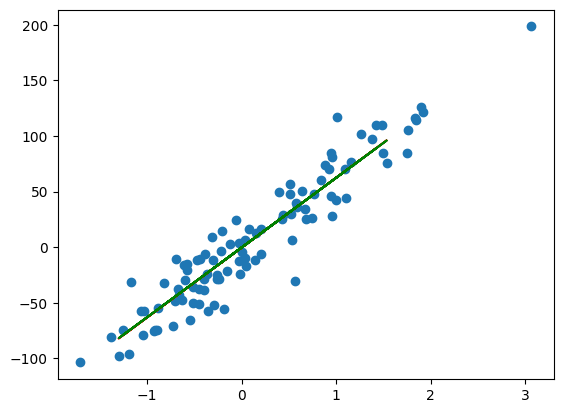

In [209]:
plt.scatter(x,y)
plt.plot(x_test,y_lr,color = 'red')
plt.plot(x_test,y_gd,color = 'green')